In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ambarish/breakhis/Folds.csv
/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/README.txt
/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/count_files.sh
/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/process_db_stat.py
/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/fibroadenoma.stat.txt
/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/phyllodes_tumor.stat.txt
/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/tubular_adenoma.stat.txt
/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/adenosis.stat.txt
/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/README_B.txt
/kaggle/input/datasets/ambarish/breakhis/BreaKH

In [2]:
# ── GPU Setup ─────────────────────────────────────────────────
import tensorflow as tf

# 1. Check GPU visibility
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {gpus}")

# 2. Enable memory growth (prevents OOM errors)
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✅ GPU enabled: {gpus[0].name}")
else:
    print("⚠️ No GPU found — running on CPU")

# 3. Confirm TensorFlow sees GPU
print(f"TF version  : {tf.__version__}")
print(f"Built with CUDA: {tf.test.is_built_with_cuda()}")
print(f"GPU available : {tf.test.is_gpu_available()}")

2026-03-22 13:02:14.068724: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774184534.227402      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774184534.273224      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774184534.644851      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774184534.644885      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774184534.644888      24 computation_placer.cc:177] computation placer alr

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
✅ GPU enabled: /physical_device:GPU:0
TF version  : 2.19.0
Built with CUDA: True
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
GPU available : True


I0000 00:00:1774184557.999731      24 gpu_device.cc:2019] Created device /device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774184558.005792      24 gpu_device.cc:2019] Created device /device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Python      : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
TensorFlow  : 2.19.0
Keras       : 3.10.0
GPU         : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
✅ Auto-found dataset at: /kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast
 Scanning image files...
✅ Total images found: 7909

Class distribution:
label
malignant    5429
benign       2480
Name: count, dtype: int64

Split → Train: 5536  Val: 1186  Test: 1187
Found 5536 validated image filenames belonging to 2 classes.
Found 1186 validated image filenames belonging to 2 classes.
Found 1187 validated image filenames belonging to 2 classes.

Class indices: {'benign': 0, 'malignant': 1}

⏳ Building ResNet50 model...


I0000 00:00:1774184564.058305      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774184564.059740      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Base model layers   : 175
Trainable layers    : 0


Model: "ResNet50_BreakHis"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...


Class weights: {0: 1.5944700460829493, 1: 0.728421052631579}

🚀 Phase 1 — Training head (base frozen)...
Epoch 1/15


I0000 00:00:1774184581.380549      73 service.cc:152] XLA service 0x7be7300150c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774184581.380588      73 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774184581.380592      73 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774184583.426067      73 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/173 ━━━━━━━━━━━━━━━━━━━━ 46:25 16s/step - accuracy: 0.4375 - auc: 0.5167 - loss: 0.9714 - precision: 0.6250 - recall: 0.2500

I0000 00:00:1774184589.331447      73 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


173/173 ━━━━━━━━━━━━━━━━━━━━ 247s 1s/step - accuracy: 0.7646 - auc: 0.8358 - loss: 0.7140 - precision: 0.8695 - recall: 0.7717 - val_accuracy: 0.8052 - val_auc: 0.9450 - val_loss: 0.5114 - val_precision: 0.9505 - val_recall: 0.7555 - learning_rate: 0.0010
Epoch 2/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 140s 810ms/step - accuracy: 0.8560 - auc: 0.9297 - loss: 0.4780 - precision: 0.9306 - recall: 0.8582 - val_accuracy: 0.9064 - val_auc: 0.9766 - val_loss: 0.3898 - val_precision: 0.9756 - val_recall: 0.8857 - learning_rate: 0.0010
Epoch 3/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 141s 815ms/step - accuracy: 0.8781 - auc: 0.9471 - loss: 0.4346 - precision: 0.9409 - recall: 0.8760 - val_accuracy: 0.9292 - val_auc: 0.9780 - val_loss: 0.3314 - val_precision: 0.9585 - val_recall: 0.9373 - learning_rate: 0.0010
Epoch 4/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 151s 872ms/step - accuracy: 0.8995 - auc: 0.9605 - loss: 0.3902 - precision: 0.9546 - recall: 0.8970 - val_accuracy: 0.9342 - val_auc: 0.9813 - val_loss: 0.3323 - v

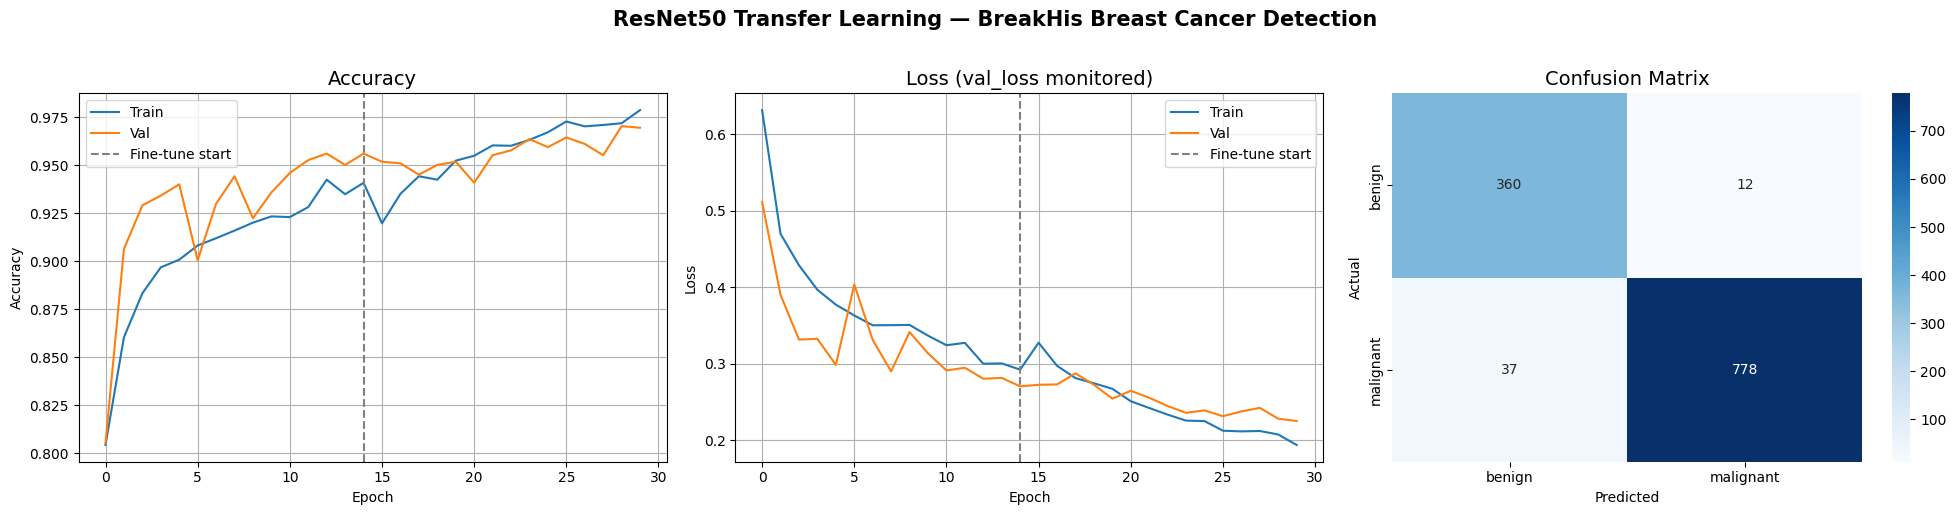


✅ Done!
   Best model saved → best_resnet50_breakhis.keras
   Results plot     → resnet50_breakhis_results.png


In [3]:


# ── Version Check ───────────────────────────────────────────────
import tensorflow as tf
import sys
print("=" * 50)
print(f"Python      : {sys.version}")
print(f"TensorFlow  : {tf.__version__}")
print(f"Keras       : {tf.keras.__version__}")
print(f"GPU         : {tf.config.list_physical_devices('GPU')}")
print("=" * 50)

# ── Imports ─────────────────────────────────────────────────────
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

from tensorflow.keras import layers, Model, regularizers, callbacks
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                              confusion_matrix, roc_auc_score)
from sklearn.utils.class_weight import compute_class_weight


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


IMG_SIZE   = 224      
BATCH_SIZE = 32
EPOCHS     = 50
LR         = 1e-5     
DROPOUT    = 0.5
L2_REG     = 1e-4



POSSIBLE_ROOTS = [
    "/kaggle/input/breakhis",
    "/kaggle/input/breakhis/BreaKHis_v1/histology_slides/breast",
    "/kaggle/input/breakhis-breast-cancer-histopathological-dataset",
]

DATASET_ROOT = None
for p in POSSIBLE_ROOTS:
    if os.path.exists(p):
        DATASET_ROOT = p
        print(f"✅ Dataset found at: {DATASET_ROOT}")
        break

if DATASET_ROOT is None:
    # Auto search
    for root, dirs, files in os.walk("/kaggle/input"):
        for d in dirs:
            if "benign" in d.lower() or "malignant" in d.lower():
                DATASET_ROOT = root
                print(f"✅ Auto-found dataset at: {DATASET_ROOT}")
                break
        if DATASET_ROOT:
            break

if DATASET_ROOT is None:
    raise RuntimeError("Dataset not found! Make sure BreakHis is added to your Kaggle notebook.")


print(" Scanning image files...")

image_paths = []
labels      = []

# Walk entire dataset root and collect all PNG/JPG files
for dirpath, _, files in os.walk(DATASET_ROOT):
    for fname in files:
        if fname.lower().endswith((".png", ".jpg", ".jpeg")):
            full_path = os.path.join(dirpath, fname)
            # Label from folder path
            path_lower = dirpath.lower()
            if "malignant" in path_lower:
                labels.append("malignant")
                image_paths.append(full_path)
            elif "benign" in path_lower:
                labels.append("benign")
                image_paths.append(full_path)

df = pd.DataFrame({"filepath": image_paths, "label": labels})
print(f"✅ Total images found: {len(df)}")
print(f"\nClass distribution:")
print(df["label"].value_counts())

if len(df) == 0:
    raise RuntimeError("No images found! Check your dataset path.")


df_train, df_temp = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df["label"]
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.50, random_state=SEED, stratify=df_temp["label"]
)

print(f"\nSplit → Train: {len(df_train)}  Val: {len(df_val)}  Test: {len(df_test)}")

# ================================================================
# STEP 4 — Data Generators
# ================================================================
# ResNet50 expects inputs preprocessed with resnet50 preprocess_input
from tensorflow.keras.applications.resnet50 import preprocess_input

# Custom generator class to apply ResNet50 preprocessing
train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    horizontal_flip        = True,
    vertical_flip          = True,
    rotation_range         = 20,
    zoom_range             = 0.15,
    width_shift_range      = 0.10,
    height_shift_range     = 0.10,
    shear_range            = 0.10,
    brightness_range       = [0.85, 1.15],
    fill_mode              = "nearest"
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

def make_generator(datagen, dataframe, shuffle=True):
    return datagen.flow_from_dataframe(
        dataframe   = dataframe,
        x_col       = "filepath",
        y_col       = "label",
        target_size = (IMG_SIZE, IMG_SIZE),
        color_mode  = "rgb",
        class_mode  = "binary",
        batch_size  = BATCH_SIZE,
        shuffle     = shuffle,
        seed        = SEED
    )

train_gen = make_generator(train_datagen, df_train, shuffle=True)
val_gen   = make_generator(val_datagen,   df_val,   shuffle=False)
test_gen  = make_generator(val_datagen,   df_test,  shuffle=False)

print(f"\nClass indices: {train_gen.class_indices}")

# ================================================================
# STEP 5 — Build ResNet50 Transfer Learning Model
# ================================================================
print("\n⏳ Building ResNet50 model...")

# Load ResNet50 with ImageNet weights, exclude top classifier
base_model = ResNet50(
    weights     = "imagenet",
    include_top = False,
    input_shape = (IMG_SIZE, IMG_SIZE, 3)
)

# ── Phase 1: Freeze all base layers (feature extraction) ────────
base_model.trainable = False
print(f"Base model layers   : {len(base_model.layers)}")
print(f"Trainable layers    : {len([l for l in base_model.layers if l.trainable])}")

# ── Build custom head ────────────────────────────────────────────
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation="relu",
                 kernel_regularizer=regularizers.l2(L2_REG))(x)
x = layers.Dropout(DROPOUT)(x)
x = layers.Dense(256, activation="relu",
                 kernel_regularizer=regularizers.l2(L2_REG))(x)
x = layers.Dropout(DROPOUT / 2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs, name="ResNet50_BreakHis")
model.summary()

# ================================================================
# STEP 6 — Phase 1 Training (Frozen base, train head only)
# ================================================================
model.compile(
    optimizer = Adam(learning_rate=1e-3),   # higher LR for head
    loss      = "binary_crossentropy",
    metrics   = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ]
)

# Class weights
labels_arr = (df_train["label"] == "malignant").astype(int).values
cw = compute_class_weight("balanced", classes=np.array([0,1]), y=labels_arr)
class_weight = {0: float(cw[0]), 1: float(cw[1])}
print(f"\nClass weights: {class_weight}")

phase1_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_loss", patience=8,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=4, min_lr=1e-7, verbose=1
    ),
]

print("\n🚀 Phase 1 — Training head (base frozen)...")
# Force model to run on GPU
with tf.device('/GPU:0'):
    history1 = model.fit(
        train_gen,
        epochs          = 15,
        validation_data = val_gen,
        class_weight    = class_weight,
        callbacks       = phase1_callbacks,
        verbose         = 1
    )
# ================================================================
# STEP 7 — Phase 2 Fine-tuning (Unfreeze last 50 layers)
# ================================================================
print("\n🔓 Unfreezing last 50 layers for fine-tuning...")
base_model.trainable = True

# Freeze all except last 50 layers
for layer in base_model.layers[:-50]:
    layer.trainable = False

trainable_count = sum(1 for l in model.layers if l.trainable)
print(f"Trainable layers after unfreeze: {trainable_count}")

# Recompile with very small LR (as requested: 0.00001)
model.compile(
    optimizer = Adam(learning_rate=LR),   # 1e-5
    loss      = "binary_crossentropy",
    metrics   = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ]
)

phase2_callbacks = [
    callbacks.ModelCheckpoint(
        filepath       = "best_resnet50_breakhis.keras",
        monitor        = "val_loss",
        mode           = "min",
        save_best_only = True,
        verbose        = 1
    ),
    callbacks.EarlyStopping(
        monitor              = "val_loss",
        patience             = 12,
        restore_best_weights = True,
        verbose              = 1
    ),
    callbacks.ReduceLROnPlateau(
        monitor   = "val_loss",
        factor    = 0.5,
        patience  = 5,
        min_lr    = 1e-8,
        verbose   = 1
    ),
]
# Force model to run on GPU
with tf.device('/GPU:0'):
    history2 = model.fit(
        train_gen,
        epochs          = 15,
        validation_data = val_gen,
        class_weight    = class_weight,
        callbacks       = phase1_callbacks,
        verbose         = 1
    )
# ================================================================
# STEP 8 — Evaluate on Test Set
# ================================================================
print("\n📊 Evaluating on test set...")
results = model.evaluate(test_gen, verbose=1)
for name, val in zip(model.metrics_names, results):
    print(f"  {name:12s}: {val:.4f}")

test_gen.reset()
y_prob = model.predict(test_gen, verbose=1).ravel()
y_pred = (y_prob >= 0.5).astype(int)
y_true = test_gen.classes

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred,
                             target_names=["benign", "malignant"]))
print(f"ROC-AUC Score : {roc_auc_score(y_true, y_prob):.4f}")

# ================================================================
# STEP 9 — Plots
# ================================================================
# Merge both training histories
def merge_history(h1, h2, key):
    return h1.history[key] + h2.history[key]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Accuracy
axes[0].plot(merge_history(history1, history2, "accuracy"),     label="Train")
axes[0].plot(merge_history(history1, history2, "val_accuracy"), label="Val")
axes[0].axvline(len(history1.history["accuracy"]) - 1,
                color="gray", linestyle="--", label="Fine-tune start")
axes[0].set_title("Accuracy", fontsize=14)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(True)

# Loss
axes[1].plot(merge_history(history1, history2, "loss"),     label="Train")
axes[1].plot(merge_history(history1, history2, "val_loss"), label="Val")
axes[1].axvline(len(history1.history["loss"]) - 1,
                color="gray", linestyle="--", label="Fine-tune start")
axes[1].set_title("Loss (val_loss monitored)", fontsize=14)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(True)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[2],
            xticklabels=["benign", "malignant"],
            yticklabels=["benign", "malignant"])
axes[2].set_title("Confusion Matrix", fontsize=14)
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual")

plt.suptitle("ResNet50 Transfer Learning — BreakHis Breast Cancer Detection",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("resnet50_breakhis_results.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✅ Done!")
print("   Best model saved → best_resnet50_breakhis.keras")
print("   Results plot     → resnet50_breakhis_results.png")

In [4]:
# ── Final Training & Validation Summary ──────────────────────
print("=" * 50)
print("       TRAINING & VALIDATION SUMMARY")
print("=" * 50)

# Get best epoch metrics from phase 2
best_val_acc  = max(history2.history["val_accuracy"])
best_val_loss = min(history2.history["val_loss"])
final_train_acc  = history2.history["accuracy"][-1]
final_val_acc    = history2.history["val_accuracy"][-1]

print(f"  Train Accuracy     : {final_train_acc * 100:.2f}%")
print(f"  Val Accuracy       : {final_val_acc   * 100:.2f}%")
print(f"  Best Val Accuracy  : {best_val_acc    * 100:.2f}%")
print(f"  Best Val Loss      : {best_val_loss:.4f}")
print("=" * 50)

# Test set
print("\n       TEST SET SUMMARY")
print("=" * 50)
test_results = model.evaluate(test_gen, verbose=0)
print(f"  Test Accuracy  : {test_results[1] * 100:.2f}%")
print(f"  Test AUC       : {test_results[2]:.4f}")
print(f"  Test Precision : {test_results[3]:.4f}")
print(f"  Test Recall    : {test_results[4]:.4f}")
print("=" * 50)

# Dataset split summary
print("\n       DATASET SPLIT SUMMARY")
print("=" * 50)
total = len(df_train) + len(df_val) + len(df_test)
print(f"  Total Images   : {total}")
print(f"  Train          : {len(df_train)} ({len(df_train)/total*100:.1f}%)")
print(f"  Validation     : {len(df_val)}  ({len(df_val)/total*100:.1f}%)")
print(f"  Test           : {len(df_test)}  ({len(df_test)/total*100:.1f}%)")
print("=" * 50)




       TRAINING & VALIDATION SUMMARY
  Train Accuracy     : 97.89%
  Val Accuracy       : 96.96%
  Best Val Accuracy  : 97.05%
  Best Val Loss      : 0.2249

       TEST SET SUMMARY
  Test Accuracy  : 95.87%
  Test AUC       : 0.9938
  Test Precision : 0.9848
  Test Recall    : 0.9546

       DATASET SPLIT SUMMARY
  Total Images   : 7909
  Train          : 5536 (70.0%)
  Validation     : 1186  (15.0%)
  Test           : 1187  (15.0%)


38/38 ━━━━━━━━━━━━━━━━━━━━ 15s 395ms/step


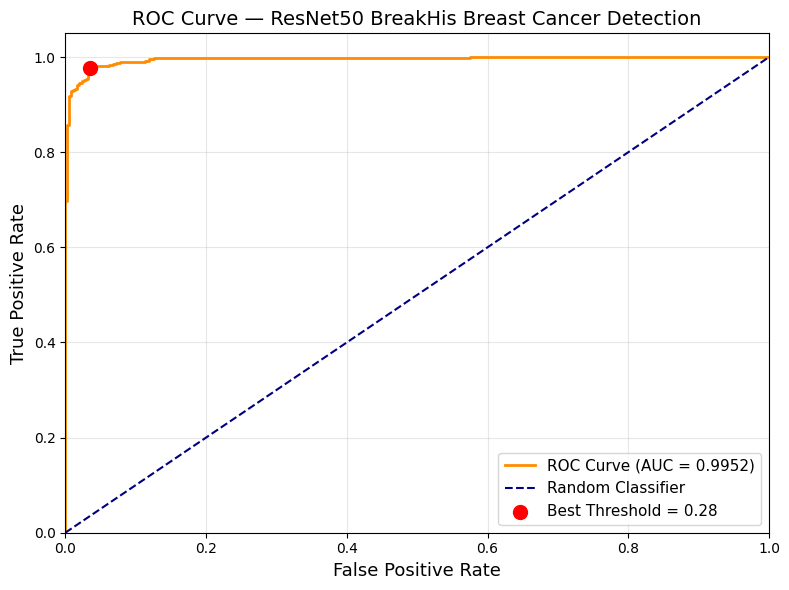


✅ ROC-AUC Score : 0.9952
   Best Threshold: 0.2829


In [5]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predictions
test_gen.reset()
y_prob = model.predict(test_gen, verbose=1).ravel()
y_true = test_gen.classes

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2,
         label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1.5,
         linestyle="--", label="Random Classifier")

# Mark best threshold point
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
plt.scatter(fpr[optimal_idx], tpr[optimal_idx],
            color="red", s=100, zorder=5,
            label=f"Best Threshold = {optimal_threshold:.2f}")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)
plt.title("ROC Curve — ResNet50 BreakHis Breast Cancer Detection", fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curve_resnet50.png", dpi=150)
plt.show()

print(f"\n✅ ROC-AUC Score : {roc_auc:.4f}")
print(f"   Best Threshold: {optimal_threshold:.4f}")




In [6]:
# ── Define the function FIRST ────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.resnet50 import preprocess_input
from PIL import Image

def predict_single_image(image_path):
    # Load image
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize((224, 224))
    img_array   = np.array(img_resized)
    img_input   = preprocess_input(img_array.copy())
    img_input   = np.expand_dims(img_input, axis=0)

    # Predict
    prob       = model.predict(img_input, verbose=0)[0][0]
    pred_label = "malignant" if prob >= 0.5 else "benign"
    confidence = prob * 100 if pred_label == "malignant" else (1 - prob) * 100

    # Show image
    plt.figure(figsize=(5, 5))
    plt.imshow(img_resized)
    plt.title(
        f"Prediction : {pred_label}\nConfidence : {confidence:.2f}%",
        fontsize=13,
        color="red" if pred_label == "malignant" else "green"
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    print(f"   Prediction  : {pred_label}")
    print(f"   Confidence  : {confidence:.2f}%")
    print(f"   Malignant % : {prob*100:.2f}%")
    print(f"   Benign %    : {(1-prob)*100:.2f}%")
    return pred_label, confidence

print(" Function defined! Now run predict_single_image()")

 Function defined! Now run predict_single_image()


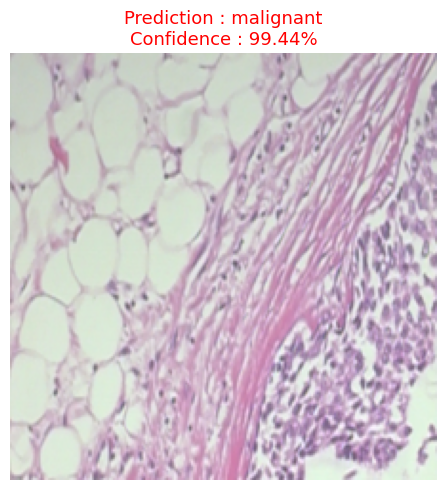

   Prediction  : malignant
   Confidence  : 99.44%
   Malignant % : 99.44%
   Benign %    : 0.56%


('malignant', np.float32(99.44367))

In [7]:
sample_path = df_test["filepath"].iloc[0]
predict_single_image(sample_path)


In [8]:
# ── Save ResNet50 BreakHis Model ─────────────────────────────
import os
import zipfile
from IPython.display import FileLink, display

# Save model in both formats
model.save('/kaggle/working/ResNet50_BreakHis_classifier.h5')
model.save('/kaggle/working/best_resnet50_breakhis.keras')
print(' Models saved!')

# Zip both files
zip_path = '/kaggle/working/breast_cancer_models.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_STORED) as zf:
    zf.write('/kaggle/working/ResNet50_BreakHis_classifier.h5',
                                'ResNet50_BreakHis_classifier.h5')
    zf.write('/kaggle/working/best_resnet50_breakhis.keras',
                                'best_resnet50_breakhis.keras')

zip_size = os.path.getsize(zip_path) / 1e6
print(f' Zip ready: {zip_size:.1f} MB')

# Download link
display(FileLink('/kaggle/working/breast_cancer_models.zip'))
print('Click the link above to download your model!')

 Models saved!
 Zip ready: 489.6 MB


/kaggle/working/breast_cancer_models.zip

Click the link above to download your model!
